# Warehouse Raster Classification Cleaning
Filter classified polygons by area threshold (>700 sqm) and rasterize back.

In [1]:
import numpy as np
import rasterio
from rasterio.features import shapes, rasterize
from shapely.geometry import shape
import geopandas as gpd

INPUT_TIF  = "output_classification.tif"
OUTPUT_TIF = "output_classification_cleaned.tif"
RESOLUTION = 3 #meter/pixel
MIN_AREA_SQM = 7500 # minimum polygon area in square metres
WAREHOUSE_VALUE = 1  # pixel value that represents 'warehouse' in the raster

In [2]:
# ── 1. Read raster ────────────────────────────────────────────────────────────
with rasterio.open(INPUT_TIF) as src:
    data      = src.read(1)          # first band
    transform = src.transform
    crs       = src.crs
    profile   = src.profile

print(f"Raster shape : {data.shape}")
print(f"Unique values: {np.unique(data)}")
print(f"CRS          : {crs}")

Raster shape : (20111, 23138)
Unique values: [0 1]
CRS          : EPSG:32616


In [3]:
# ── 2. Vectorise warehouse pixels → polygons ──────────────────────────────────
mask = (data == WAREHOUSE_VALUE).astype(np.uint8)

geoms = [
    {"geometry": geom, "value": val}
    for geom, val in shapes(mask, transform=transform)
    if val == 1          # keep only warehouse shapes
]

gdf = gpd.GeoDataFrame(
    [{"geometry": shape(g["geometry"]), "value": g["value"]} for g in geoms],
    crs=crs
)

print(f"Total warehouse polygons : {len(gdf)}")

Total warehouse polygons : 99328


In [4]:
# ── 3. Calculate area & tag true / false warehouse ────────────────────────────
pixel_area = RESOLUTION ** 2          # 9 sqm per pixel

# If the raster is in a projected CRS (metres) use geometry area directly;
# otherwise fall back to pixel-count × pixel_area.
if crs and crs.is_projected:
    gdf["area_sqm"] = gdf.geometry.area
else:
    # Count pixels per polygon via the vectorised pixel count approximation
    gdf["area_sqm"] = gdf.geometry.area   # degrees – may be inaccurate
    print("WARNING: CRS is geographic (degrees). Area may be inaccurate. "
          "Consider reprojecting to a metre-based CRS.")

gdf["warehouse"] = gdf["area_sqm"] >= MIN_AREA_SQM

true_wh  = gdf["warehouse"].sum()
false_wh = (~gdf["warehouse"]).sum()
print(f"True  warehouse polygons (≥{MIN_AREA_SQM} sqm): {true_wh}")
print(f"False warehouse polygons (<{MIN_AREA_SQM} sqm): {false_wh}")

True  warehouse polygons (≥7500 sqm): 931
False warehouse polygons (<7500 sqm): 98397


In [5]:
# 4. Rasterize back 
# Encoding: 2 = true warehouse  |  1 = false warehouse  |  0 = non-warehouse
out_shape = data.shape

def burn_value(row):
    return 2 if row["warehouse"] else 1

shapes_iter = (
    (geom, burn_value(row))
    for _, row in gdf.iterrows()
    for geom in [row.geometry.__geo_interface__]
)

burned = rasterize(
    ((geom, val) for _, row in gdf.iterrows()
                 for geom, val in [(row.geometry.__geo_interface__, burn_value(row))]),
    out_shape=out_shape,
    transform=transform,
    fill=0, # non-warehouse
    dtype=np.uint8
)

print(f"Output pixel value counts: { {v: int((burned==v).sum()) for v in np.unique(burned)} }")
# 0 = non-warehouse, 1 = false warehouse, 2 = true warehouse

Output pixel value counts: {np.uint8(0): 460668961, np.uint8(1): 1645891, np.uint8(2): 3013466}


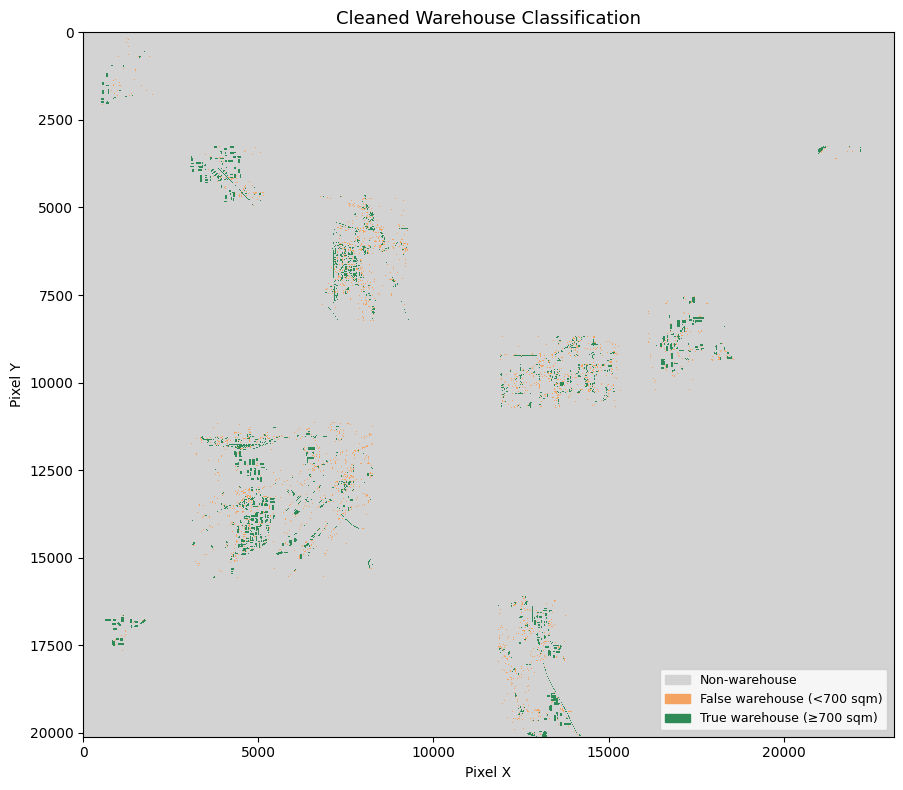

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#d3d3d3", "#f4a460", "#2e8b57"])
labels = ["Non-warehouse", "False warehouse (<700 sqm)", "True warehouse (≥700 sqm)"]
colors = ["#d3d3d3", "#f4a460", "#2e8b57"]

fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(burned, cmap=cmap, vmin=0, vmax=2, interpolation="nearest")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax.legend(handles=patches, loc="lower right", fontsize=9)

ax.set_title("Cleaned Warehouse Classification", fontsize=13)
ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")
plt.tight_layout()
plt.show()

In [7]:
# ── 5. Save cleaned raster ────────────────────────────────────────────────────
profile.update(dtype=rasterio.uint8, count=1, nodata=None)

with rasterio.open(OUTPUT_TIF, "w", **profile) as dst:
    dst.write(burned, 1)

print(f"Saved cleaned raster: {OUTPUT_TIF}")

Saved cleaned raster: output_classification_cleaned.tif


In [8]:
# 4. Rasterize back 
# Encoding: 1 = true warehouse  | 0 = non-warehouse
out_shape = data.shape

def burn_value(row):
    return 1 if row["warehouse"] else 0

shapes_iter = (
    (geom, burn_value(row))
    for _, row in gdf.iterrows()
    for geom in [row.geometry.__geo_interface__]
)

burned = rasterize(
    ((geom, val) for _, row in gdf.iterrows()
                 for geom, val in [(row.geometry.__geo_interface__, burn_value(row))]),
    out_shape=out_shape,
    transform=transform,
    fill=0, # non-warehouse
    dtype=np.uint8
)

print(f"Output pixel value counts: { {v: int((burned==v).sum()) for v in np.unique(burned)} }")
# 0 = non-warehouse, 1 = true warehouse

Output pixel value counts: {np.uint8(0): 322932690, np.uint8(1): 10689462}


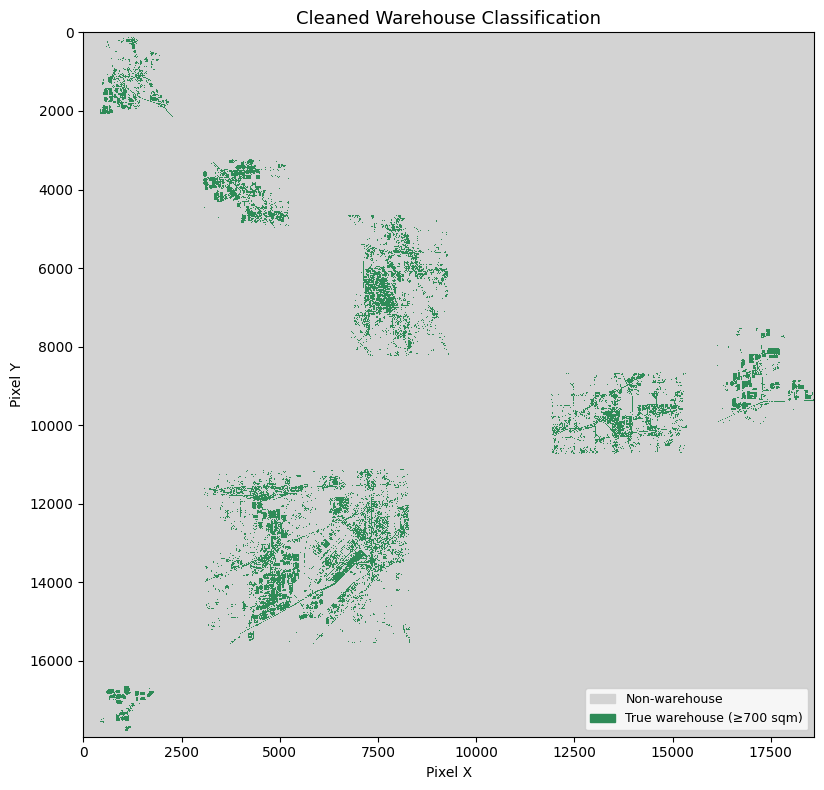

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#d3d3d3", "#2e8b57"])
labels = ["Non-warehouse", "True warehouse (≥700 sqm)"]
colors = ["#d3d3d3", "#2e8b57"]

fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(burned, cmap=cmap, vmin=0, vmax=2, interpolation="nearest")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax.legend(handles=patches, loc="lower right", fontsize=9)

ax.set_title("Cleaned Warehouse Classification", fontsize=13)
ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")
plt.tight_layout()
plt.show()